In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
data = pd.read_csv('kenya.csv', comment='#')


In [33]:
data['Country'] = 'Kenya'

In [34]:
data['Date']=pd.to_datetime(data['YEAR'] * 1000 + data['DOY'], format = '%Y%j')

In [35]:
data['Month']=data['Date'].dt.month

In [36]:
data = data.replace(-999, np.nan)

In [37]:
duplicates = data.duplicated().sum()
print(f"Total number of duplicates {duplicates}")

Total number of duplicates 0


### Duplicates

There are **0** duplicates in the whole dataset.

In [38]:
data.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,20.427600,27.838717,14.673169,13.165548,1.468162,65.845355,3.061765,4.375241,83.724335,11.052539,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,15.260000,18.880000,8.970000,4.110000,0.000000,28.420000,0.610000,1.160000,83.310000,4.780000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,19.460000,26.297500,13.700000,11.467500,0.100000,58.677500,2.420000,3.670000,83.630000,9.880000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,20.360000,27.875000,14.750000,13.260000,0.380000,66.220000,3.140000,4.430000,83.720000,11.005000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,21.400000,29.520000,15.750000,15.050000,1.360000,73.280000,3.720000,5.090000,83.810000,12.350000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,25.400000,34.270000,18.750000,20.120000,51.650000,91.070000,5.280000,7.590000,84.170000,15.040000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.440824,2.358770,1.415691,2.605174,3.180228,9.934196,0.853218,0.992156,0.126391,1.607151,NaN,3.477046


### Statistics Interpretation

The dataset contains 4,108 rows and covers years from 2015 through 2026, with month values spanning 1 to 12, so the analysis includes all seasons.

- `T2M` averages around 20.4°C with a narrow interquartile range, indicating relatively stable daily temperatures.
- `T2M_MAX` and `T2M_MIN` averages of 27.8°C and 14.7°C imply a consistent daily temperature swing of about 12–14°C.
- `PRECTOTCORR` is highly skewed: the mean is 1.47 mm, but the maximum reaches 51.65 mm, meaning most days are light or dry and a few days are very rainy.
- `RH2M` averages 65.8% with values ranging from about 28% to 91%, showing generally moderate humidity with occasional very humid conditions.
- `WS2M` and `WS2M_MAX` show mostly light-to-moderate winds, with average speeds near 3–4 m/s.
- `PS` is very stable around 83.7 with minimal variation, suggesting steady pressure conditions.
- `QV2M` is also relatively stable around 11 g/kg, matching the moderate moisture levels in the air.

Overall, the summary points to a stable tropical/subtropical climate: consistent temperatures, moderate atmospheric moisture, and strong precipitation skew with episodic heavy rainfall.


In [39]:
data.isna().sum()

YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
Date           0
Month          0
dtype: int64

### Null Values

There are 0 null values.


In [40]:
columns = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']

In [41]:
z_scores = (data[columns] - data[columns].mean()) / data[columns].std()

In [42]:
outliers = (np.abs(z_scores) > 3).any(axis=1)

outlier_count = outliers.sum()
print(f"Total number of outlier rows: {outlier_count}")

Total number of outlier rows: 120


In [43]:
data[columns] = data[columns].clip(
    lower=data[columns].quantile(0.01),
    upper=data[columns].quantile(0.99),
    axis=1
)

### Outlier Detection and Basic Cleaning

Since this is a weather dataset, natural spikes are expected. That's why I have decided to cap the outliers 

instead of deleting them. They were identified using a z-score of greater than 3. They are capped using 1st anf 

99th percentile. This preserved important extreme weather events while reducing the influence of noisy values.

In [44]:
data.to_csv('data/kenya_clean.csv', index = False)

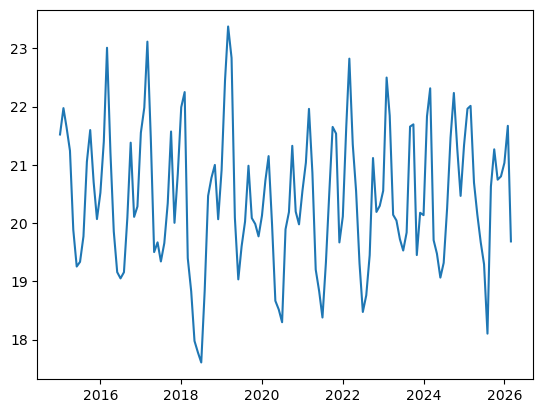

In [45]:
monthly_temp = data.groupby(['YEAR', 'Month'])['T2M'].mean().reset_index()
monthly_temp["Date"] = pd.to_datetime(
    monthly_temp["YEAR"].astype(str) + "-" + monthly_temp["Month"].astype(str)
)

plt.figure()
plt.plot(monthly_temp["Date"], monthly_temp["T2M"])

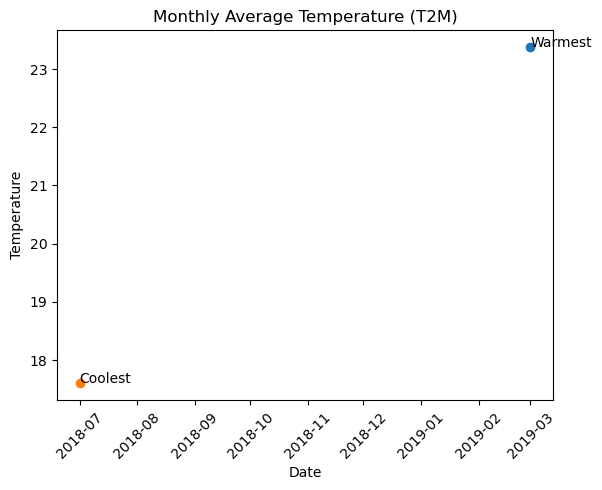

In [46]:
max_row = monthly_temp.loc[monthly_temp["T2M"].idxmax()]
min_row = monthly_temp.loc[monthly_temp["T2M"].idxmin()]

plt.scatter(max_row["Date"], max_row["T2M"])
plt.scatter(min_row["Date"], min_row["T2M"])

plt.text(max_row["Date"], max_row["T2M"], "Warmest")
plt.text(min_row["Date"], min_row["T2M"], "Coolest")

plt.title("Monthly Average Temperature (T2M)")
plt.xlabel("Date")
plt.ylabel("Temperature")
plt.xticks(rotation=45)
plt.show()

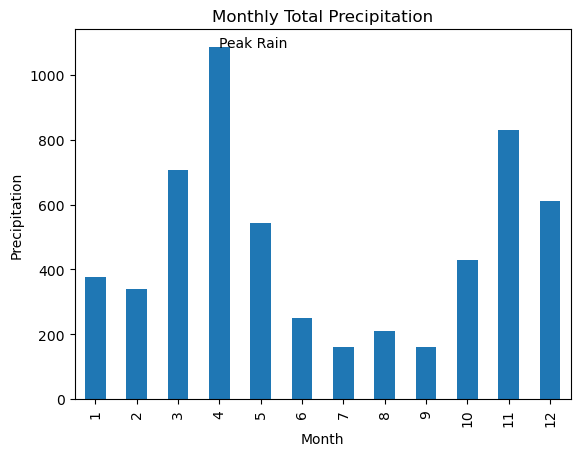

In [47]:
monthly_rain = data.groupby('Month')['PRECTOTCORR'].sum()

plt.figure()
monthly_rain.plot(kind="bar")

# Highlight peak
peak_month = monthly_rain.idxmax()
peak_value = monthly_rain.max()

plt.text(peak_month-1, peak_value, "Peak Rain")

plt.title("Monthly Total Precipitation")
plt.xlabel("Month")
plt.ylabel("Precipitation")
plt.show()

### Analysis

Temperature varies seasonally with clear warm and cool periods. The peak rainfall is recorded on April. As for 

the temperature, the coolest is recording in the seventh month of the year 2018 and the warmest on March of 2019.

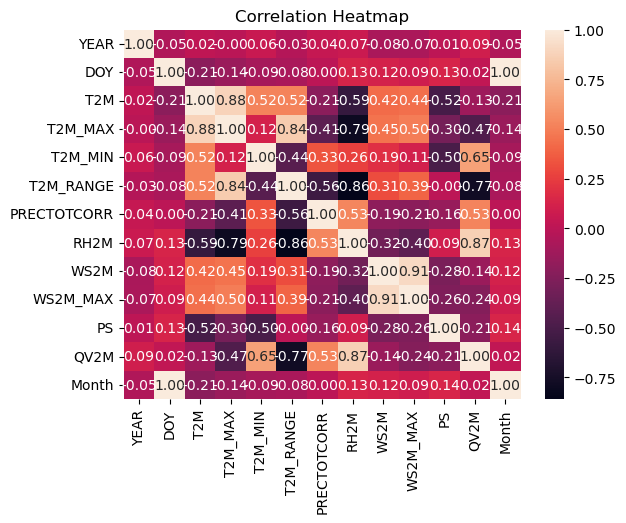

In [48]:
plt.figure()
corr = data.corr(numeric_only=True)

sns.heatmap(corr, annot=True, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

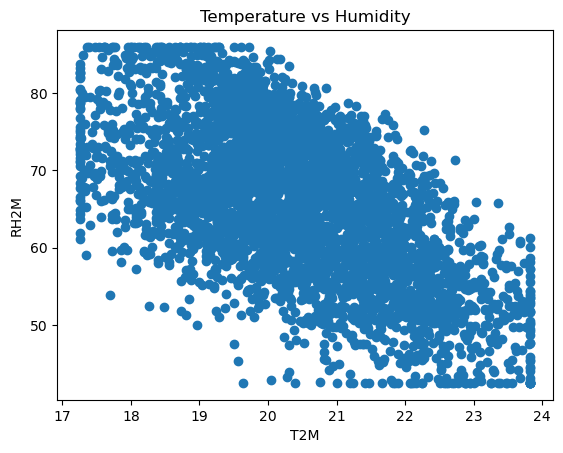

In [49]:
plt.figure()
plt.scatter(data["T2M"], data["RH2M"])
plt.xlabel("T2M")
plt.ylabel("RH2M")
plt.title("Temperature vs Humidity")
plt.show()

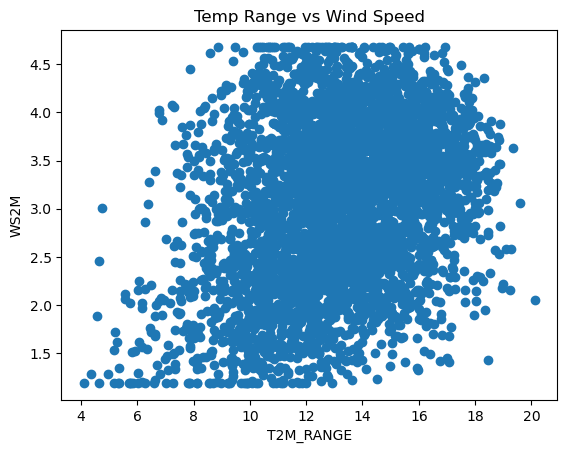

In [50]:
plt.figure()
plt.scatter(data["T2M_RANGE"], data["WS2M"])
plt.xlabel("T2M_RANGE")
plt.ylabel("WS2M")
plt.title("Temp Range vs Wind Speed")
plt.show()

In [51]:
corr_pairs = corr.unstack().sort_values(ascending=False)
corr_pairs = corr_pairs[corr_pairs < 1]  

print(corr_pairs.head(7))

Month     DOY         0.996557
DOY       Month       0.996557
WS2M_MAX  WS2M        0.911103
WS2M      WS2M_MAX    0.911103
T2M       T2M_MAX     0.881267
T2M_MAX   T2M         0.881267
QV2M      RH2M        0.868198
dtype: float64


The strongest correlations in the dataset highlight both redundancy in features and meaningful physical relationships.

Month and DOY show an almost perfect correlation (~0.997), confirming that they represent the same underlying temporal progression and are effectively interchangeable.

Wind-related variables also exhibit a strong relationship, with WS2M and WS2M_MAX (~0.91) closely aligned. This suggests that average and peak wind speeds tend to rise and fall together, indicating relatively stable wind behavior without extreme variability.

Temperature variables show a similarly strong connection, with T2M and T2M_MAX (~0.88) being highly correlated. This indicates that days with higher average temperatures generally also experience higher maximum temperatures, reflecting consistent daily heating patterns.

Moisture variables remain strongly linked as well, with QV2M and RH2M (~0.87) showing a high correlation. This reinforces the idea that different measures of atmospheric moisture move together and capture similar environmental conditions.

Overall, the dataset contains some expected redundancy (especially in time and closely related physical measurements), alongside clear environmental relationships between temperature, wind, and atmospheric moisture variables.

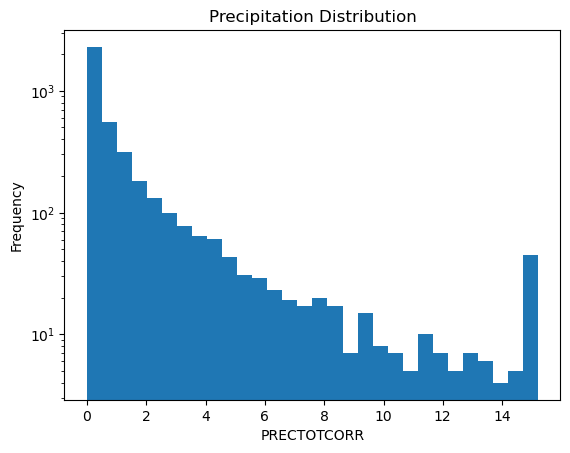

In [52]:
plt.figure()
plt.hist(data["PRECTOTCORR"], bins=30)

plt.yscale("log")  # helps if skewed

plt.title("Precipitation Distribution")
plt.xlabel("PRECTOTCORR")
plt.ylabel("Frequency")
plt.show()

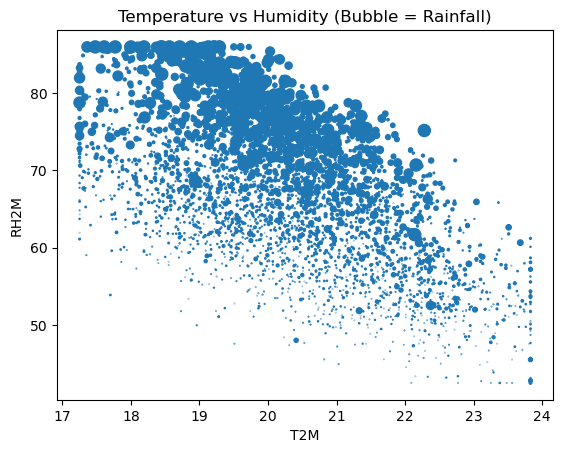

In [53]:
plt.figure()
plt.scatter(
    data["T2M"],
    data["RH2M"],
    s=data["PRECTOTCORR"] * 5  
)

plt.xlabel("T2M")
plt.ylabel("RH2M")
plt.title("Temperature vs Humidity (Bubble = Rainfall)")
plt.show()